**MAIN GOAL** : Cluster loyal versus disengaged customers by behavioral and financial 
attributes. Mine rules such as: customers from Germany holding only one 
product who are inactive represent a strong churn profile. Detect anomalies 
in sudden balance drops preceding account closure.


# Phase 1 : Data Understanding and Preprocessing

P1 Goal : Produce a clean, analysis-ready dataset and document every preprocessing 
decision with justification. This phase establishes the factual foundation for all 
subsequent mining steps

## EDA

### Importing libraries and loading dataset

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('../data/raw/churn.csv')

### Data Types and Missing Values

In [43]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [44]:
# missing value
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [45]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Check unique values for object data

In [46]:
print( "Surname Unique counts:", df['Surname'].value_counts())


Surname Unique counts: Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
            ..
Izmailov     1
Bold         1
Bonham       1
Poninski     1
Burbidge     1
Name: count, Length: 2932, dtype: int64


In [47]:
print("Geography Unique counts:", df['Geography'].value_counts())

Geography Unique counts: Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64


In [48]:
print("Gender counts:", df['Gender'].value_counts())

Gender counts: Gender
Male      5457
Female    4543
Name: count, dtype: int64


### Outlier detection

In [49]:
# Note: We identify outliers but do not drop them here, as Phase 4 
# requires cross-referencing anomalies with Phase 2 cluster outliers.

numeric_cols = df.select_dtypes(include=['number']).columns
cols_to_check = [col for col in numeric_cols if col not in ['RowNumber', 'CustomerId', 'HasCrCard', 'IsActiveMember', 'Exited']]

def detect_outliers_iqr(data, columns):
    outlier_indices = []
    
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)].index
        outlier_indices.extend(outliers)
        
        print(f"Column: {col} | Outliers detected: {len(outliers)}")
        
    return list(set(outlier_indices))

outlier_list = detect_outliers_iqr(df, cols_to_check)
outlier_df = df.loc[outlier_list]

Column: CreditScore | Outliers detected: 15
Column: Age | Outliers detected: 359
Column: Tenure | Outliers detected: 0
Column: Balance | Outliers detected: 0
Column: NumOfProducts | Outliers detected: 60
Column: EstimatedSalary | Outliers detected: 0


### Graph Distribution of numerical features

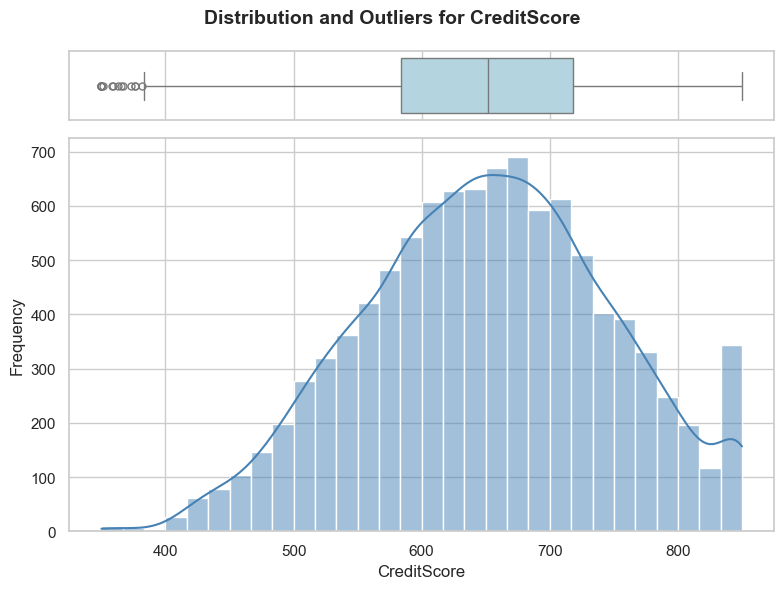

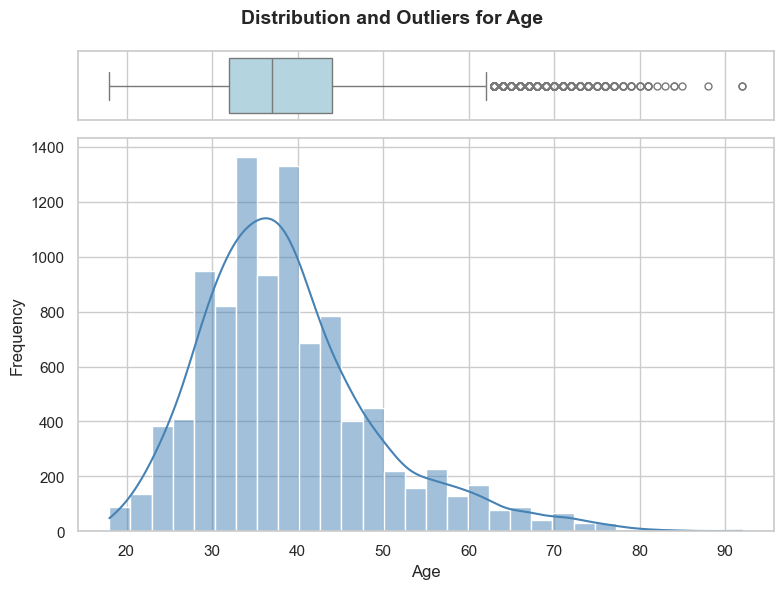

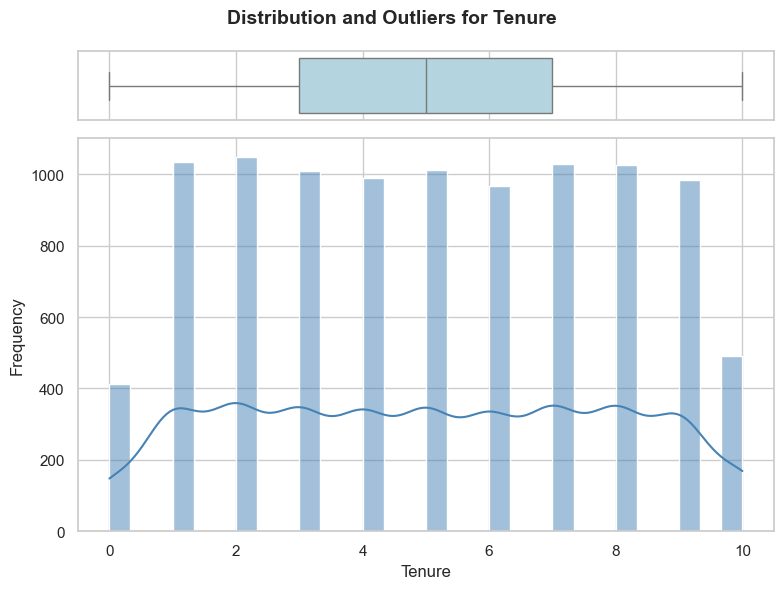

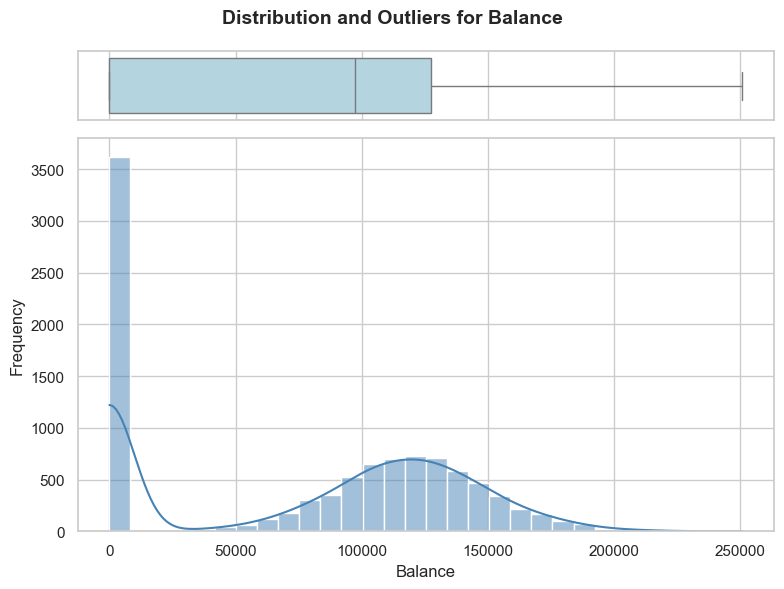

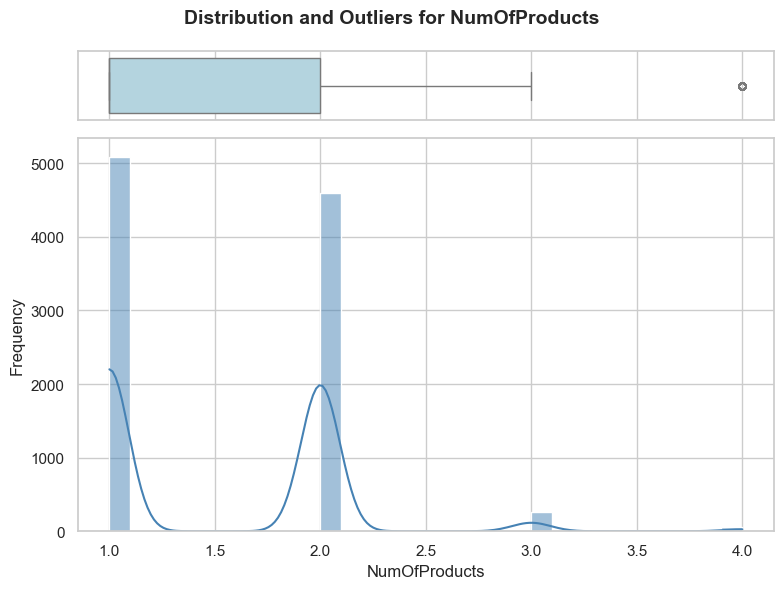

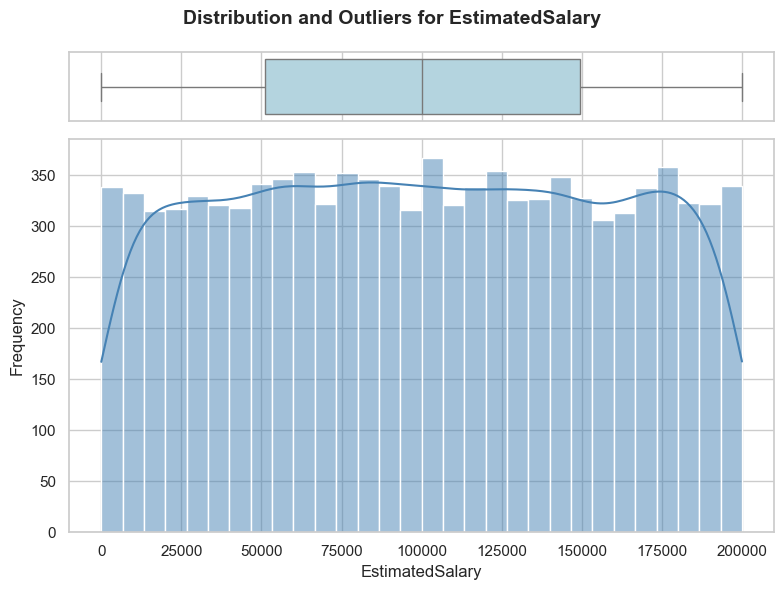

In [50]:
# 1. Define your numerical columns (excluding IDs and binary flags)
cols_to_check = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

# 2. Set the visual style
sns.set_theme(style="whitegrid")

# 3. Loop through each column and create a combined graph
for col in cols_to_check:
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(8, 6))
    
    sns.boxplot(x=df[col], ax=ax_box, color='lightblue', flierprops=dict(marker='o', color='red', markersize=5))
    sns.histplot(data=df, x=col, kde=True, ax=ax_hist, color='steelblue', bins=30)
    
    ax_box.set(xlabel='') 
    ax_hist.set(xlabel=col, ylabel='Frequency')
    
    plt.suptitle(f'Distribution and Outliers for {col}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Graph Count of object features

C:\Users\Thomas\AppData\Local\Temp\ipykernel_54876\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


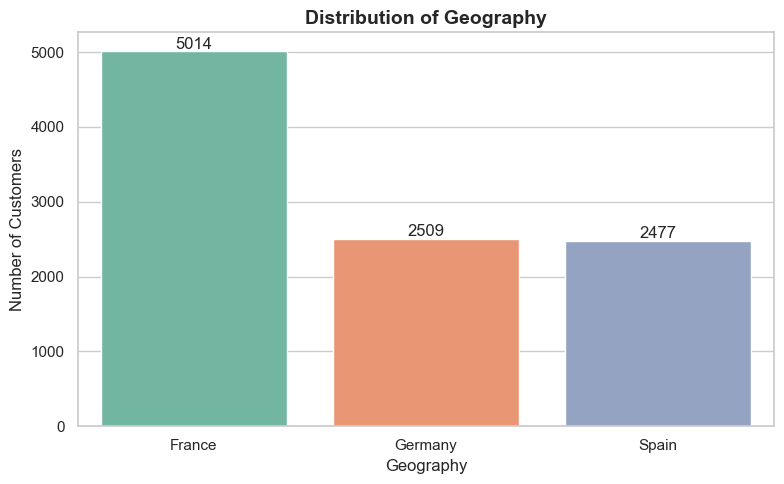

C:\Users\Thomas\AppData\Local\Temp\ipykernel_54876\2446648625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)


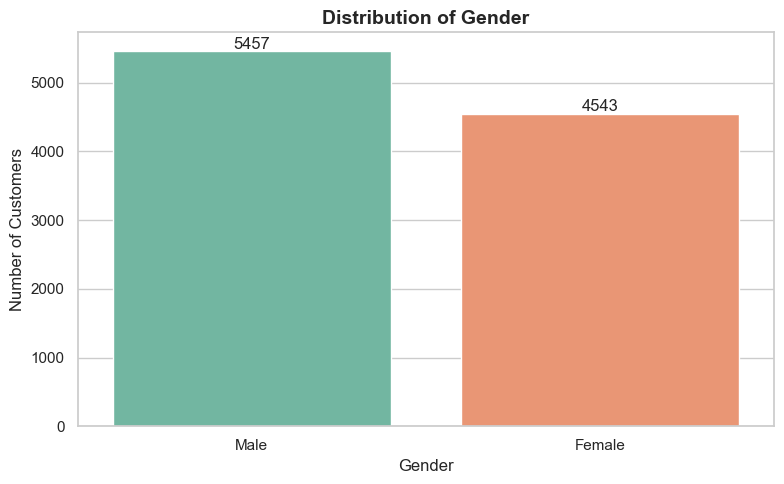

In [51]:
object_cols = df.select_dtypes(include=['object']).columns
cols_to_exclude = ['RowNumber', 'CustomerId', 'Surname']
cols_to_plot = [col for col in object_cols if col not in cols_to_exclude]

sns.set_theme(style="whitegrid")

for col in cols_to_plot:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=col, palette="Set2", order=df[col].value_counts().index)
    
    plt.title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 5), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

## Apply data cleaning

In [52]:
# Step 1: Basic Cleaning
df_clean = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
df_clean.drop_duplicates(inplace=True)
df_clean.dropna(inplace=True)

print("Dataset shape after cleaning:", df_clean.shape)
df_clean.head()

Dataset shape after cleaning: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Conduct feature selection using correlation analysis and entropy measures

### Pearson Correlation Heatmap and Feature Redundancy Analysis

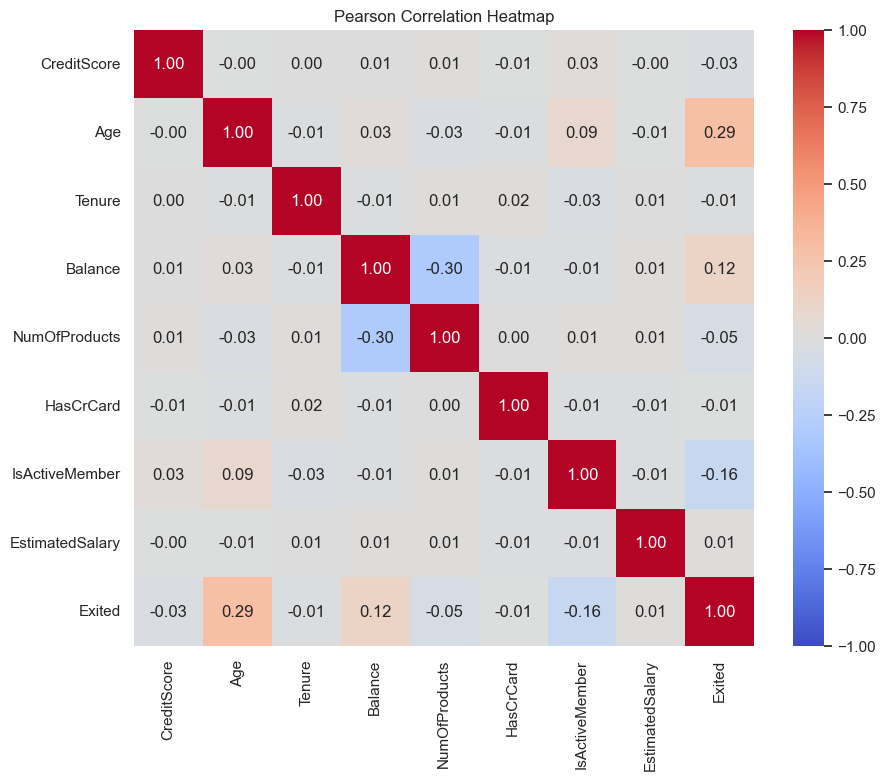

In [53]:
# Pearson Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
numeric_cols = df_clean.select_dtypes(include=['number'])
correlation_matrix = numeric_cols.corr(method='pearson')
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Pearson Correlation Heatmap')
plt.show()

In [54]:
# UNSUPERVISED Feature Redundancy Analysis
# Instead of supervised mutual_info_classif (which requires a target label),
# we analyze pairwise Pearson correlations to identify redundant features.
# This is appropriate for unsupervised discovery tasks.
import numpy as np

corr_matrix = numeric_cols.corr(method='pearson').abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Flag pairs with correlation > 0.85
threshold = 0.85
high_corr_pairs = []
for col in upper_tri.columns:
    for row in upper_tri.index:
        val = upper_tri.loc[row, col]
        if pd.notna(val) and val > threshold:
            high_corr_pairs.append((row, col, val))

if high_corr_pairs:
    print(f'Highly correlated feature pairs (r > {threshold}):')
    for f1, f2, r in high_corr_pairs:
        print(f'  {f1} <-> {f2}: r = {r:.3f}')
else:
    print(f'No highly correlated feature pairs found (threshold: {threshold})')
    print('All features provide independent information - suitable for clustering.')


No highly correlated feature pairs found (threshold: 0.85)
All features provide independent information - suitable for clustering.


#### EDA: Distribution of the 'Exited' Feature

Note: This is exploratory analysis of the Exited feature distribution,
not a supervised class-imbalance diagnostic. In our unsupervised pipeline,
Exited is treated as just another feature for pattern discovery.

C:\Users\Thomas\AppData\Local\Temp\ipykernel_54876\2829317231.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='Exited', palette='Set1')


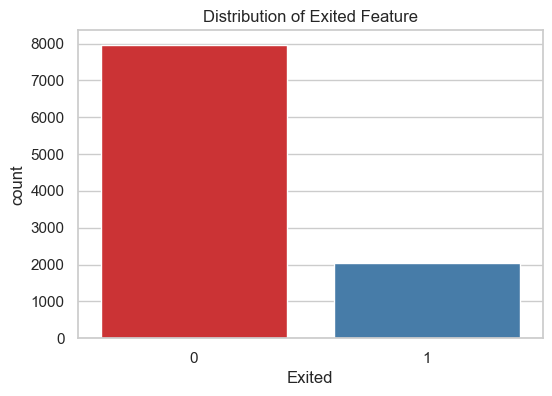

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [55]:
# EDA: Distribution of the Exited feature (not a target variable)
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x='Exited', palette='Set1')
plt.title('Distribution of Exited Feature')
plt.show()

# Print percentages
print(df_clean['Exited'].value_counts(normalize=True) * 100)

## Perform data transformation: normalization, encoding, and binning of continuous variables

In [56]:
from sklearn.preprocessing import StandardScaler
import os

# Create directory if it doesn't exist
os.makedirs('../data/processed', exist_ok=True)

# Path A: The Distance Matrix (For K-Means & Isolation Forest)
df_matrix = df_clean.copy()

# Scale Numericals: StandardScaler (Z-score)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
df_matrix[num_cols] = scaler.fit_transform(df_matrix[num_cols])

# Encode Categoricals: One-Hot Encoding
df_matrix = pd.get_dummies(df_matrix, columns=['Geography', 'Gender'], drop_first=True)

# Save Path A output
matrix_path = '../data/processed/churn_clustering_matrix.csv'
df_matrix.to_csv(matrix_path, index=False)
print(f"Distance Matrix saved to {matrix_path}")

df_matrix.head()

Distance Matrix saved to ../data/processed/churn_clustering_matrix.csv


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,False,True,False


In [57]:
# Path B: The Transaction Matrix (For Apriori)
df_trans = df_clean.copy()

# Bin Numericals (Discretize) — ALL numericals must be categorical for Apriori
df_trans['Age'] = pd.cut(df_trans['Age'], bins=[0, 25, 60, 150], labels=['Youth', 'Adult', 'Senior'])

# Balance: Zero Balance, Low, Medium, High
balance_bins = [-1, 0, 50000, 100000, float('inf')]
balance_labels = ['Zero Balance', 'Low', 'Medium', 'High']
df_trans['Balance'] = pd.cut(df_trans['Balance'], bins=balance_bins, labels=balance_labels)

# CreditScore: Poor, Fair, Good, Excellent
df_trans['CreditScore'] = pd.qcut(df_trans['CreditScore'], q=4, labels=['Poor', 'Fair', 'Good', 'Excellent'])

# Tenure: Short, Medium, Long, VeryLong (FIX: was previously left as raw integer)
df_trans['Tenure'] = pd.cut(df_trans['Tenure'], bins=[-1, 2, 5, 8, 10],
                            labels=['Short', 'Medium', 'Long', 'VeryLong'])

# NumOfProducts: convert to labeled string (FIX: was previously left as raw integer)
df_trans['NumOfProducts'] = df_trans['NumOfProducts'].astype(str) + ' Products'

# EstimatedSalary: quartile bins (FIX: was previously left as raw float)
df_trans['EstimatedSalary'] = pd.qcut(df_trans['EstimatedSalary'], q=4,
                                      labels=['LowSalary', 'MidLowSalary', 'MidHighSalary', 'HighSalary'])

# Strings kept as they are (Geography, Gender)

# Map Binary Flags
df_trans['HasCrCard'] = df_trans['HasCrCard'].map({0: "No Credit Card", 1: "Has Credit Card"})
df_trans['IsActiveMember'] = df_trans['IsActiveMember'].map({0: "Inactive", 1: "Active"})

# Map Target
df_trans['Exited'] = df_trans['Exited'].map({0: "Retained", 1: "Churned"})

# Save Path B output
trans_path = '../data/processed/churn_transactions.csv'
df_trans.to_csv(trans_path, index=False)
print(f"Transaction Matrix saved to {trans_path}")

df_trans.head()


Transaction Matrix saved to ../data/processed/churn_transactions.csv


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Fair,France,Female,Adult,Short,Zero Balance,1 Products,Has Credit Card,Active,MidHighSalary,Churned
1,Fair,Spain,Female,Adult,Short,Medium,1 Products,No Credit Card,Active,MidHighSalary,Retained
2,Poor,France,Female,Adult,Long,High,3 Products,Has Credit Card,Inactive,MidHighSalary,Churned
3,Good,France,Female,Adult,Short,Zero Balance,2 Products,No Credit Card,Inactive,MidLowSalary,Retained
4,Excellent,Spain,Female,Adult,Short,High,1 Products,Has Credit Card,Active,MidLowSalary,Retained


## Deliverable: Clean dataset file and Preprocessing Report

In [58]:
# Export cleaned data
clean_data_path = '../data/processed/churn_clean.csv'
df_clean.to_csv(clean_data_path, index=False)
print(f"Clean data saved to {clean_data_path}")

Clean data saved to ../data/processed/churn_clean.csv
